In [128]:
"""

================================================================================

CLIMATE ANALYTICS: NATURAL CAPITAL & ECONOMIC GROWTH

================================================================================

PROJECT OVERVIEW:

Analyzes Germany and Brazil's wealth composition using World Bank's

"Changing Wealth of Nations" (CWON) dataset.

Key Questions:

- How does natural capital contribute to total wealth?

- What are the trends in renewable vs non-renewable capital?

- How do capital components correlate with economic growth?

METHODOLOGY:

Extended Cobb-Douglas Production Function:

Y = A × K^α × H^β × R^γ × N^δ

Where:

- Y = National comprehensive wealth (output)

- K = Produced capital (infrastructure, machinery)

- H = Human capital (labor, education)

- R = Renewable natural capital (forests, cropland, fisheries)

- N = Non-renewable natural capital (oil, gas, minerals)

DATA SOURCE:

World Bank - The Changing Wealth of Nations (CWON)

Period: 1995-2020 (Annual, per capita, 2019 USD chained)

Coverage: 193 countries

================================================================================

"""

'\n\n================================================================================\n\nCLIMATE ANALYTICS: NATURAL CAPITAL & ECONOMIC GROWTH\n\n================================================================================\n\nPROJECT OVERVIEW:\n\nAnalyzes Germany and Brazil\'s wealth composition using World Bank\'s\n\n"Changing Wealth of Nations" (CWON) dataset.\n\nKey Questions:\n\n- How does natural capital contribute to total wealth?\n\n- What are the trends in renewable vs non-renewable capital?\n\n- How do capital components correlate with economic growth?\n\nMETHODOLOGY:\n\nExtended Cobb-Douglas Production Function:\n\nY = A × K^α × H^β × R^γ × N^δ\n\nWhere:\n\n- Y = National comprehensive wealth (output)\n\n- K = Produced capital (infrastructure, machinery)\n\n- H = Human capital (labor, education)\n\n- R = Renewable natural capital (forests, cropland, fisheries)\n\n- N = Non-renewable natural capital (oil, gas, minerals)\n\nDATA SOURCE:\n\nWorld Bank - The Changing Wealth of

In [129]:
import pandas as pd

In [130]:
import numpy as np

In [131]:
import matplotlib.pyplot as plt

In [132]:
import seaborn as sns

============================================================================

SECTION 1: DATA LOADING & EXPLORATION

============================================================================

In [133]:
"""

PURPOSE:

Load raw CWON dataset and explore its structure.

WHAT WE DO:

1. Read CSV file (469,984 rows × 37 columns)

2. Display dataset shape and column names

3. Check data types and missing values

4. Show sample data

"""

'\n\nPURPOSE:\n\nLoad raw CWON dataset and explore its structure.\n\nWHAT WE DO:\n\n1. Read CSV file (469,984 rows × 37 columns)\n\n2. Display dataset shape and column names\n\n3. Check data types and missing values\n\n4. Show sample data\n\n'

In [134]:
def load_data(filepath):

    """Load CWON dataset and return basic info."""

    df = pd.read_csv(filepath)

    print("=" * 80)

    print("DATASET LOADING")

    print("=" * 80)

    print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")

    print(f"\nColumn Names:\n{df.columns.tolist()}")

    print(f"\nData Types:\n{df.dtypes}")

    print(f"\nMissing Values:\n{df.isnull().sum()}")

    return df

============================================================================

SECTION 2: DATA CLEANING & PREPARATION

============================================================================

In [135]:
"""

PURPOSE:

Clean messy column names and select relevant indicators.

WHAT WE DO:

1. Rename 37 columns to meaningful names

2. Keep only relevant columns: country, indicator, year, value

3. Remove redundant/metadata columns

4. Prepare data for country-specific filtering

"""

'\n\nPURPOSE:\n\nClean messy column names and select relevant indicators.\n\nWHAT WE DO:\n\n1. Rename 37 columns to meaningful names\n\n2. Keep only relevant columns: country, indicator, year, value\n\n3. Remove redundant/metadata columns\n\n4. Prepare data for country-specific filtering\n\n'

In [136]:
def clean_columns(df):

    """Rename raw columns to clean, readable names."""

    column_mapping = {

        'REF_AREA': 'country',

        'INDICATOR_LABEL': 'indicator',

        'TIME_PERIOD': 'year',

        'OBS_VALUE': 'value'

    }

    df_clean = df.rename(columns=column_mapping)

    df_clean = df_clean[['country', 'indicator', 'year', 'value']]

    df_clean['year'] = pd.to_numeric(df_clean['year'], errors='coerce')

    df_clean['value'] = pd.to_numeric(df_clean['value'], errors='coerce')

    return df_clean

============================================================================

SECTION 3: COUNTRY-SPECIFIC DATA EXTRACTION

============================================================================

In [137]:
"""

PURPOSE:

Filter data for specific countries and select key indicators.

WHAT WE DO:

1. Filter to one country (Germany or Brazil)

2. Select 7 key capital indicators

3. Reshape from long to wide format (year × indicator)

4. Compute time-series statistics

"""

'\n\nPURPOSE:\n\nFilter data for specific countries and select key indicators.\n\nWHAT WE DO:\n\n1. Filter to one country (Germany or Brazil)\n\n2. Select 7 key capital indicators\n\n3. Reshape from long to wide format (year × indicator)\n\n4. Compute time-series statistics\n\n'

In [138]:
KEY_INDICATORS = [

    'Produced capital',

    'Human capital',

    'Renewable natural capital',

    'Nonrenewable natural capital',

    'Foreign assets',

    'Foreign liabilities',

    'National comprehensive wealth' ]

In [139]:
def extract_country_data(df_clean, country_name):

    """

    Filter to single country and key indicators.

    Parameters:

    -----------

    df_clean : pd.DataFrame

        Cleaned CWON data

    country_name : str

        Country to extract (e.g., 'Germany', 'Brazil')

    Returns:

    --------

    df_country : pd.DataFrame

        Long-format data for country

    df_wide : pd.DataFrame

        Wide-format (year × indicator) for time-series analysis

    """

    df_country = df_clean[df_clean['country'] == country_name].copy()

    df_country = df_country[df_country['indicator'].isin(KEY_INDICATORS)].copy()

    # Pivot to wide format

    df_wide = df_country.pivot_table(

        index='year',

        columns='indicator',

        values='value'
    ).sort_index()

    df_wide.index.name = 'Year'

    print(f"\n{'='*80}")

    print(f"COUNTRY DATA: {country_name.upper()}")

    print(f"{'='*80}")

    print(f"Time period: {df_wide.index.min():.0f} - {df_wide.index.max():.0f}")

    print(f"Years available: {len(df_wide)}")

    print(f"\nIndicators extracted:")

    for col in df_wide.columns:

        print(f" - {col}")

    return df_country, df_wide

============================================================================

SECTION 4: DESCRIPTIVE STATISTICS

============================================================================

In [140]:
"""

PURPOSE:

Compute key metrics: average wealth, growth rates, volatility, shares.

WHAT WE DO:

1. Calculate year-on-year % growth rates

2. Compute average shares (% of total wealth)

3. Compute volatility (std-dev of growth rates)

4. Display summary statistics table

"""

'\n\nPURPOSE:\n\nCompute key metrics: average wealth, growth rates, volatility, shares.\n\nWHAT WE DO:\n\n1. Calculate year-on-year % growth rates\n\n2. Compute average shares (% of total wealth)\n\n3. Compute volatility (std-dev of growth rates)\n\n4. Display summary statistics table\n\n'

In [141]:
def compute_statistics(df_wide):

    """

    Compute growth rates, shares, and volatility.

    Parameters:

    -----------

    df_wide : pd.DataFrame

        Wide-format wealth data (year × indicator)

    Returns:

    --------

    growth_rates : pd.DataFrame

        Year-on-year % growth for each indicator

    shares : pd.DataFrame

        % share of each indicator in total wealth

    stats_summary : pd.DataFrame

        Summary table (mean, std, min, max)

    """

    growth_rates = df_wide.pct_change() * 100

    # Shares (% of total comprehensive wealth)

    total_wealth = df_wide['National comprehensive wealth']

    shares = (df_wide.div(total_wealth, axis=0) * 100).drop('National comprehensive wealth', axis=1)

    # Summary statistics

    stats_summary = pd.DataFrame({

        'Avg_Share_%': shares.mean(),

        'Avg_Growth_%_per_year': growth_rates.mean(),

        'Volatility_std_%': growth_rates.std(),

        'Min_Value': df_wide.min(),

        'Max_Value': df_wide.max()

    })

    print(f"\n{'='*80}")

    print("DESCRIPTIVE STATISTICS")

    print(f"{'='*80}")

    print("\nAverage Share of Total Wealth (%):")

    print(shares.mean().round(2))

    print("\nAverage Annual Growth Rate (%):")

    print(growth_rates.mean().round(2))

    print("\nVolatility - Std Dev of Growth (%):")

    print(growth_rates.std().round(2))

    return growth_rates, shares, stats_summary

============================================================================

SECTION 5: VISUALIZATION - TIME SERIES & COMPOSITION

============================================================================

In [142]:
"""

PURPOSE:

Create informative plots for trends and composition analysis.

WHAT WE DO:

1. Indexed time-series (all capitals relative to baseline)

2. Stacked area chart (wealth composition over time)

3. Year-on-year growth rates (volatility and trends)

4. Correlation heatmaps

"""

'\n\nPURPOSE:\n\nCreate informative plots for trends and composition analysis.\n\nWHAT WE DO:\n\n1. Indexed time-series (all capitals relative to baseline)\n\n2. Stacked area chart (wealth composition over time)\n\n3. Year-on-year growth rates (volatility and trends)\n\n4. Correlation heatmaps\n\n'

In [143]:
def plot_indexed_levels(df_wide, country_name):

    """Plot indexed time-series (first year = 100)."""

    df_indexed = (df_wide / df_wide.iloc[0] * 100)

    plt.figure(figsize=(14, 6))

    for col in df_indexed.columns:

        plt.plot(df_indexed.index, df_indexed[col], marker='o', label=col, linewidth=2)

    plt.title(f'{country_name} - Wealth & Capital Components (Indexed, first year = 100)',

              fontsize=14, fontweight='bold')

    plt.xlabel('Year', fontsize=12)

    plt.ylabel('Index (first year = 100)', fontsize=12)

    plt.legend(loc='best', fontsize=10)

    plt.grid(True, alpha=0.3)

    plt.tight_layout()

    plt.show()

In [144]:
def plot_composition(shares, country_name):

    """Plot stacked area chart of wealth composition."""

    plt.figure(figsize=(14, 6))

    shares.plot(kind='area', stacked=True, alpha=0.8)

    plt.title(f'{country_name} - Composition of National Comprehensive Wealth',

              fontsize=14, fontweight='bold')

    plt.xlabel('Year', fontsize=12)

    plt.ylabel('Share of Total Wealth (%)', fontsize=12)

    plt.legend(loc='upper left', fontsize=10, ncol=2)

    plt.tight_layout()

    plt.show()

In [145]:
def plot_correlations(df_wide, country_name):

    """Plot correlation heatmaps for levels."""

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Correlation of levels

    corr_levels = df_wide.corr()

    sns.heatmap(corr_levels, annot=True, fmt='.2f', cmap='RdBu_r', center=0,

                ax=axes[0], cbar_kws={'label': 'Correlation'})

    axes[0].set_title(f'{country_name} - Correlation (Levels)', fontsize=12, fontweight='bold')


============================================================================

============================================================================

SECTION 6: SCENARIO ANALYSIS - CLIMATE STRESS TESTING

============================================================================

In [146]:
"""

PURPOSE:

Test how wealth changes under natural capital stress scenarios.

WHAT WE DO:

1. Create baseline scenario (historical data)

2. Create stress scenarios: renewable NC declines by 5%, 10%, 20%

3. Use trained ML model to predict wealth under each scenario

4. Quantify wealth loss relative to baseline

5. Inform policy on climate vulnerability

"""

'\n\nPURPOSE:\n\nTest how wealth changes under natural capital stress scenarios.\n\nWHAT WE DO:\n\n1. Create baseline scenario (historical data)\n\n2. Create stress scenarios: renewable NC declines by 5%, 10%, 20%\n\n3. Use trained ML model to predict wealth under each scenario\n\n4. Quantify wealth loss relative to baseline\n\n5. Inform policy on climate vulnerability\n\n'

============================================================================

MAIN EXECUTION

============================================================================

In [147]:
"""

PURPOSE:

Orchestrate full analysis pipeline for both countries.

EXECUTION ORDER:

1. Load data

2. Clean columns

3. Extract Germany data → compute stats → visualize

4. Extract Brazil data → compute stats → visualize

5. Run stress-test scenarios

6. Save results and plots

"""

'\n\nPURPOSE:\n\nOrchestrate full analysis pipeline for both countries.\n\nEXECUTION ORDER:\n\n1. Load data\n\n2. Clean columns\n\n3. Extract Germany data → compute stats → visualize\n\n4. Extract Brazil data → compute stats → visualize\n\n5. Run stress-test scenarios\n\n6. Save results and plots\n\n'

Loading CWON dataset...
DATASET LOADING
Shape: 469984 rows × 37 columns

Column Names:
['STRUCTURE', 'STRUCTURE_ID', 'ACTION', 'FREQ', 'FREQ_LABEL', 'REF_AREA', 'REF_AREA_LABEL', 'INDICATOR', 'INDICATOR_LABEL', 'SEX', 'SEX_LABEL', 'AGE', 'AGE_LABEL', 'URBANISATION', 'URBANISATION_LABEL', 'UNIT_MEASURE', 'UNIT_MEASURE_LABEL', 'COMP_BREAKDOWN_1', 'COMP_BREAKDOWN_1_LABEL', 'COMP_BREAKDOWN_2', 'COMP_BREAKDOWN_2_LABEL', 'COMP_BREAKDOWN_3', 'COMP_BREAKDOWN_3_LABEL', 'TIME_PERIOD', 'OBS_VALUE', 'AGG_METHOD', 'AGG_METHOD_LABEL', 'DATABASE_ID', 'DATABASE_ID_LABEL', 'UNIT_MULT', 'UNIT_MULT_LABEL', 'UNIT_TYPE', 'UNIT_TYPE_LABEL', 'TIME_FORMAT', 'TIME_FORMAT_LABEL', 'OBS_CONF', 'OBS_CONF_LABEL']

Data Types:
STRUCTURE                  object
STRUCTURE_ID               object
ACTION                     object
FREQ                       object
FREQ_LABEL                 object
REF_AREA                   object
REF_AREA_LABEL             object
INDICATOR                  object
INDICATOR_LABEL       

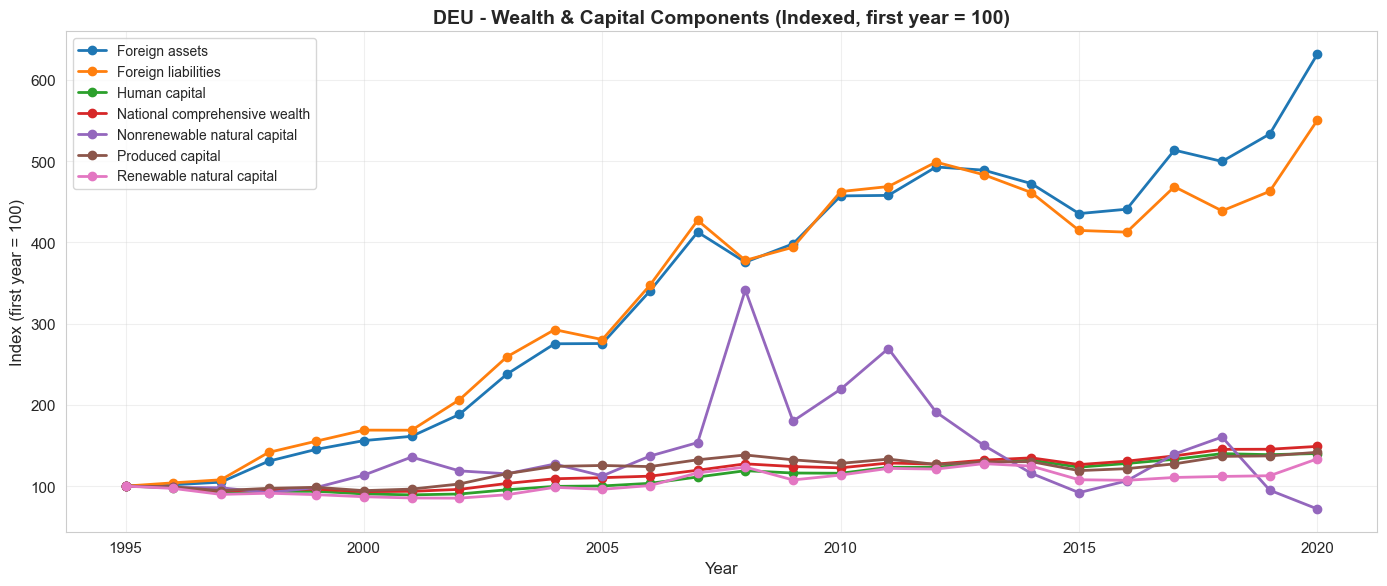

<Figure size 1400x600 with 0 Axes>

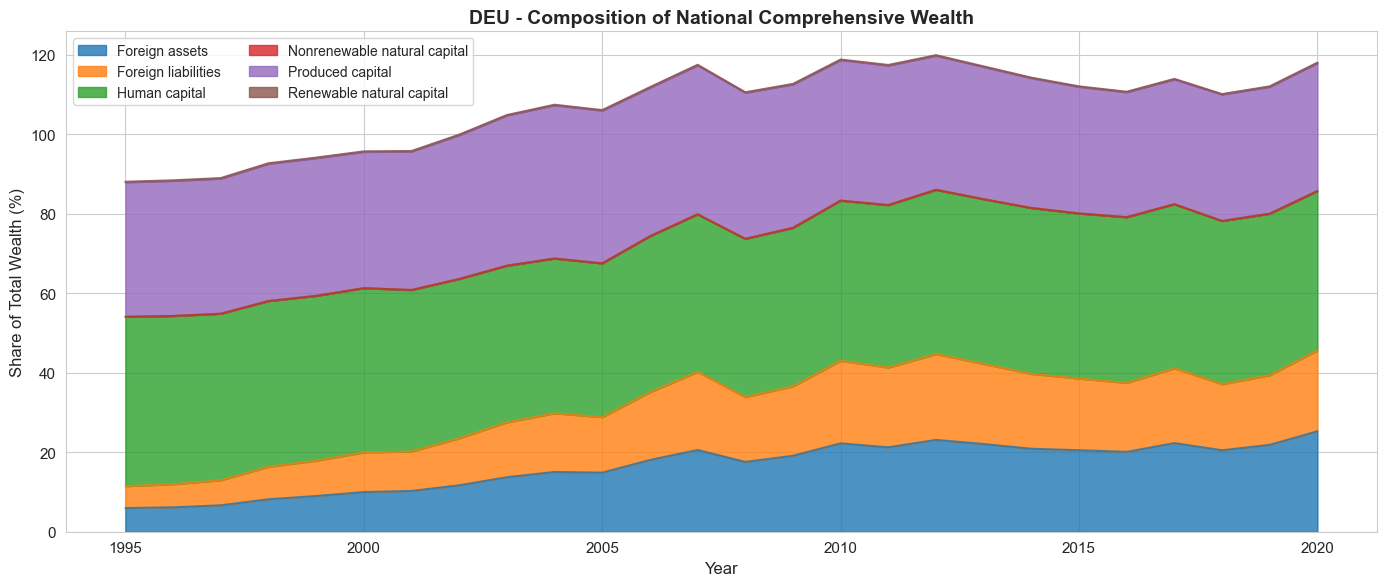



Processing BRAZIL data...

COUNTRY DATA: BRA
Time period: 1995 - 2020
Years available: 26

Indicators extracted:
 - Foreign assets
 - Foreign liabilities
 - Human capital
 - National comprehensive wealth
 - Nonrenewable natural capital
 - Produced capital
 - Renewable natural capital

DESCRIPTIVE STATISTICS

Average Share of Total Wealth (%):
indicator
Foreign assets                   4.01
Foreign liabilities              8.71
Human capital                   48.66
Nonrenewable natural capital     0.55
Produced capital                14.17
Renewable natural capital        2.83
dtype: float64

Average Annual Growth Rate (%):
indicator
Foreign assets                    5.05
Foreign liabilities               4.97
Human capital                     3.30
National comprehensive wealth     3.04
Nonrenewable natural capital     11.49
Produced capital                  2.23
Renewable natural capital         1.08
dtype: float64

Volatility - Std Dev of Growth (%):
indicator
Foreign assets        

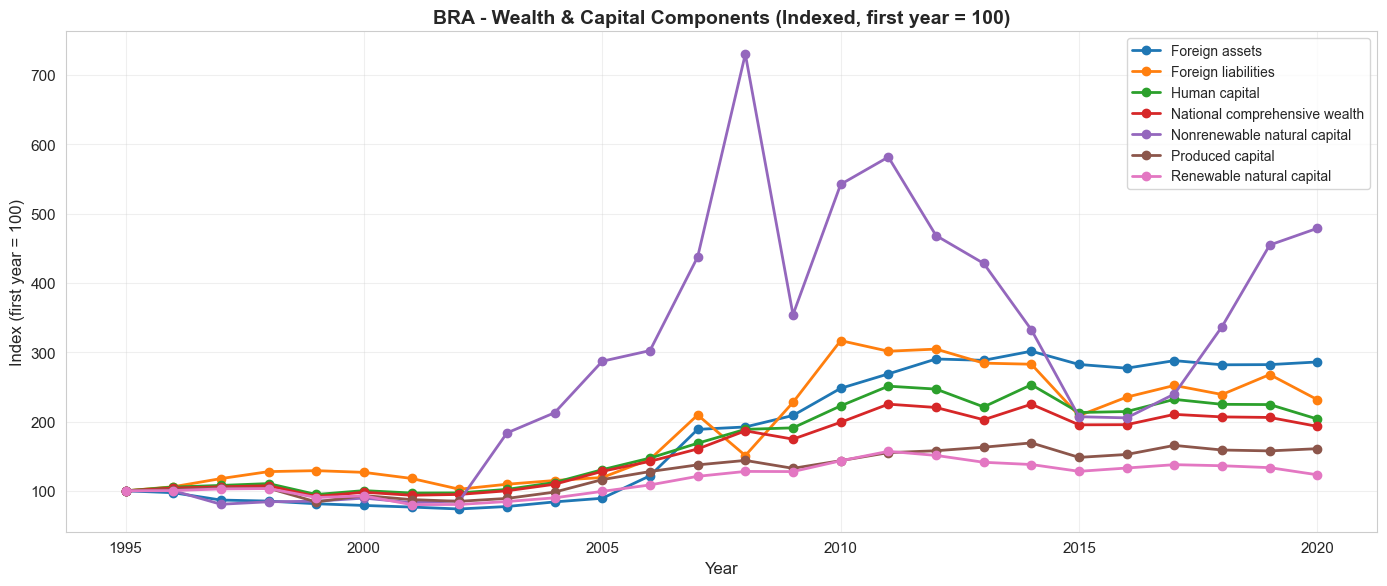

<Figure size 1400x600 with 0 Axes>

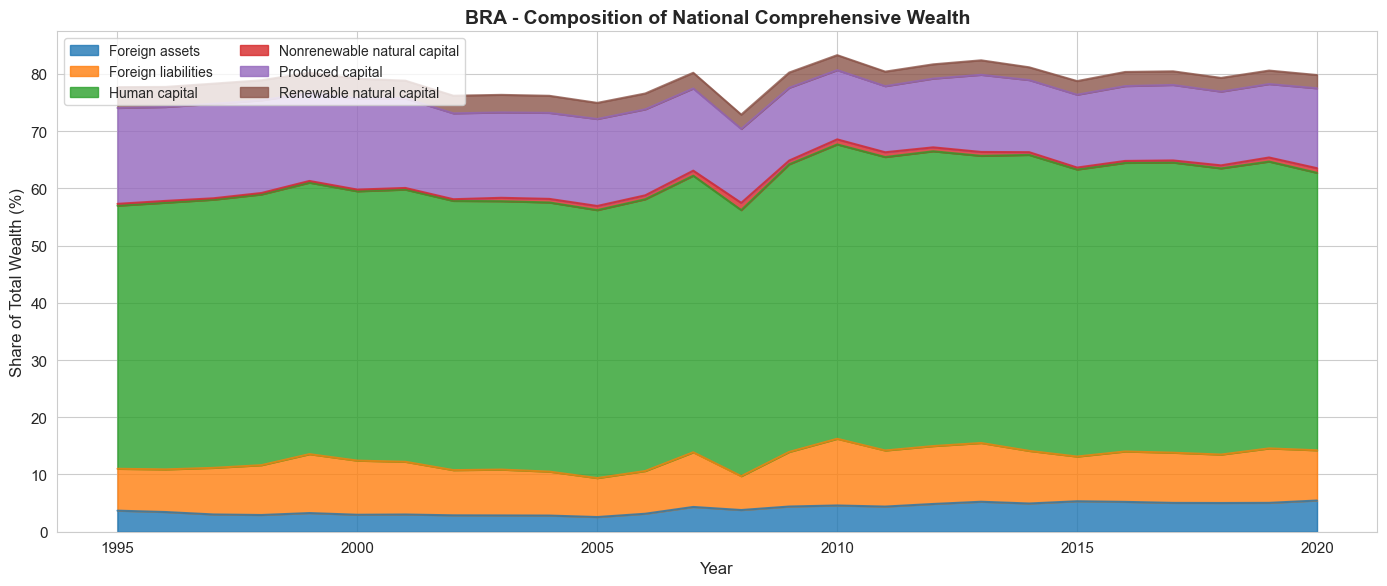


ANALYSIS COMPLETE


In [148]:
if __name__ == '__main__':

    # Step 1: Load and clean data

    print("Loading CWON dataset...")

    df = load_data("WB_CWON.csv")

    df_clean = clean_columns(df)

    # Step 2: Germany analysis

    print("\n\nProcessing GERMANY data...")

    df_germany_long, df_germany = extract_country_data(df_clean, 'DEU')

    growth_de, shares_de, stats_de = compute_statistics(df_germany)

    plot_indexed_levels(df_germany, 'DEU')

    plot_composition(shares_de, 'DEU')

    # Step 3: Brazil analysis (optional)

    print("\n\nProcessing BRAZIL data...")

    df_brazil_long, df_brazil = extract_country_data(df_clean, 'BRA')

    growth_br, shares_br, stats_br = compute_statistics(df_brazil)

    plot_indexed_levels(df_brazil, 'BRA')

    plot_composition(shares_br, 'BRA')

    print("\n" + "="*80)

    print("ANALYSIS COMPLETE")

    print("="*80)